### 1. Module 1 — Regression

- This module contains all regression-related logic and contains:
    - Setup (import path + constants)
    - Library Imports
    - Load training data

In [1]:
# --- Cell 4: regression ------------------------------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 50)
import sys
from pathlib import Path

DATA_PATH = "data/RMBR4-2_export_test.csv"

df = pd.read_csv(DATA_PATH)

print("Shape:", df.shape)
print("Columns:", list(df.columns))
df.head()
# Make `src` importable regardless of how the notebook was launched
PROJECT_ROOT = Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# Axis names — the target of each regression
AXES = [f"Axis #{i}" for i in range(1, 9)]

print("Project root:", PROJECT_ROOT)
print("Axes:", AXES)

from src.regression.regression_model import (
    prepare_time_column,
    train_regression_models,
    add_predictions_and_residuals,
)

# 4a. Add time_seconds
df = prepare_time_column(df)

# 4b. Fit Time -> Axis for each axis
models, regression_summary = train_regression_models(df, AXES)

# 4c. Add prediction + residual columns
df = add_predictions_and_residuals(df, models, AXES)

# 4d. Show the summary table
regression_summary

Shape: (39672, 16)
Columns: ['Trait', 'Axis #1', 'Axis #2', 'Axis #3', 'Axis #4', 'Axis #5', 'Axis #6', 'Axis #7', 'Axis #8', 'Axis #9', 'Axis #10', 'Axis #11', 'Axis #12', 'Axis #13', 'Axis #14', 'Time']
Project root: c:\Users\User\Code\FoundationMLCourse\DataStreamVisualization_Workshop
Axes: ['Axis #1', 'Axis #2', 'Axis #3', 'Axis #4', 'Axis #5', 'Axis #6', 'Axis #7', 'Axis #8']


,Axis,Slope,Intercept,R2
0,Axis #1,-1.176729e-07,0.730542,1.584839e-06
1,Axis #2,2.194203e-06,3.523886,5.442193e-05
2,Axis #3,-5.777186e-07,2.733898,6.833765e-06
3,Axis #4,3.890034e-07,0.604357,3.264337e-05
4,Axis #5,8.381178e-08,0.951103,8.520927e-07
5,Axis #6,4.744455e-07,0.580077,3.654041e-05
6,Axis #7,5.537186e-07,0.847563,3.494045e-05
7,Axis #8,8.499989e-08,0.098748,2.159701e-05


### Module 2 — Threshold discovery
- This module contains the Q90/Q95/Q99 analysis

In [2]:
from src.thresholds.threshold_discovery import (
    calculate_residual_summary,
    discover_thresholds,
)

# 1. Per-axis residual statistics
residual_summary = calculate_residual_summary(df, AXES)
residual_summary

,Axis,Mean,Std,Min,Q90,Q95,Q99,Q995,Max
0,Axis #1,-5.731339e-17,2.162118,-0.730542,1.384551,3.622423,10.637570,13.023465,22.881511
1,Axis #2,2.980296e-16,6.879775,-3.701166,8.072280,13.548942,27.827261,35.563784,48.082660
2,Axis #3,3.668057e-16,5.111883,-2.733898,5.199893,9.756149,22.004903,25.752864,39.160990
3,Axis #4,6.304473e-17,1.574871,-0.635786,1.458227,2.506291,7.724843,10.433111,15.054179
4,Axis #5,-8.023874e-17,2.100185,-0.957874,2.943088,4.106583,8.931155,11.537336,19.796448
5,Axis #6,-1.203581e-16,1.815465,-0.618410,0.742746,2.498980,9.737241,12.129149,20.320990
6,Axis #7,-1.719402e-16,2.166773,-0.892300,2.260198,7.175265,7.227199,7.238041,7.260771
7,Axis #8,0.000000e+00,0.423071,-0.105615,0.032236,0.096614,2.866628,3.489369,5.802731


- Derive Thershold

In [3]:
# 2. Derive thresholds
thresholds = discover_thresholds(
    df, AXES,
    alert_percentile=0.95,
    error_percentile=0.99,
    time_threshold=5,
)

# Pretty-print
import pandas as pd
thresholds_df = pd.DataFrame(thresholds).T
thresholds_df.index.name = "Axis"
thresholds_df

,MinC,MaxC,T
Axis,,,
Axis #1,3.622423,10.637570,5.0
Axis #2,13.548942,27.827261,5.0
Axis #3,9.756149,22.004903,5.0
Axis #4,2.506291,7.724843,5.0
Axis #5,4.106583,8.931155,5.0
Axis #6,2.498980,9.737241,5.0
Axis #7,7.175265,7.227199,5.0
Axis #8,0.096614,2.866628,5.0


### Threshold Justification and Axis Selection

Alert (`MinC = Q95`) and Error (`MaxC = Q99`) thresholds are dynamically calculated from each axis's residual distribution rather than using fixed limits.

Two axes require notable consideration:
* **Axis #8:** `Q95` (0.097) is significantly smaller than `Std` (0.423), reflecting a tight core with rare spikes up to `Q99` (2.87). This extreme 30× gap between Alert and Error levels prevents a balanced demonstration.
* **Axis #7:** `Q95` (7.175) and `Q99` (7.227) are almost identical, leaving no operational gap between Alert and Error triggers.

**Axis #2** is selected for primary demonstration because its residuals are well-behaved (`Std = 6.88`), its thresholds are cleanly separated (`MinC = 13.55`, `MaxC = 27.83`—a ~2× ratio), and its values allow clear visualization of distinct Alert and Error events.

### Module 3 — Synthetic data
- This is where the code we're currently working on should eventually go.

In [4]:
from src.synthetic_data.generator import generate_synthetic_test_data

synthetic_df = generate_synthetic_test_data(
    df=df,
    model=models["Axis #2"],
    axis="Axis #2",
    min_c=thresholds["Axis #2"]["MinC"],
    max_c=thresholds["Axis #2"]["MaxC"],
)
synthetic_df.to_csv("data/synthetic_test_data.csv", index=False)

print("Shape:", synthetic_df.shape)
print("Segments:", synthetic_df["segment"].value_counts().to_dict())

Shape: (62, 6)
Segments: {'normal': 20, 'recovery': 20, 'alert': 8, 'error': 8, 'gap': 6}


- Save the file and reload from disk

In [5]:
synthetic_df.to_csv("data/synthetic_test_data.csv", index=False)

from pathlib import Path
p = Path("data/synthetic_test_data.csv")
print("Exists:", p.exists(), "| size:", p.stat().st_size, "bytes")

# Reload to prove it round-trips
import pandas as pd
reloaded = pd.read_csv("data/synthetic_test_data.csv", parse_dates=["Time"])
print("Reloaded shape:", reloaded.shape)

Exists: True | size: 6703 bytes
Reloaded shape: (62, 6)


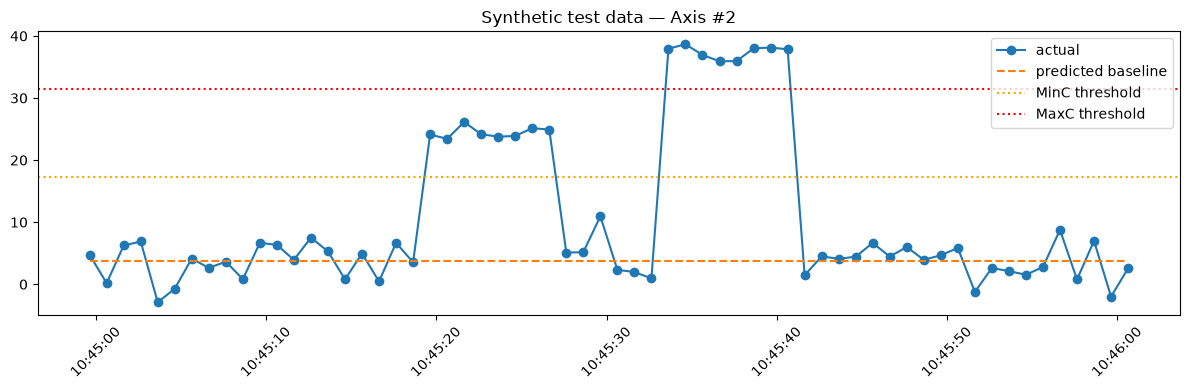

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))
plt.plot(reloaded["Time"], reloaded["Axis #2"], marker="o", label="actual")
plt.plot(reloaded["Time"], reloaded["Axis #2_prediction"],
         linestyle="--", label="predicted baseline")
plt.axhline(reloaded["Axis #2_prediction"].mean() + thresholds["Axis #2"]["MinC"],
            color="orange", linestyle=":", label="MinC threshold")
plt.axhline(reloaded["Axis #2_prediction"].mean() + thresholds["Axis #2"]["MaxC"],
            color="red", linestyle=":", label="MaxC threshold")
plt.title("Synthetic test data — Axis #2")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Module 4 — Anomaly detector

- This is probably the most important module to detect anomal behavior of Axes.
- The important part is that update() receives one streaming observation at a time

In [7]:
import sys
for name in list(sys.modules.keys()):
    if "anomaly_detector" in name:
        del sys.modules[name]
        print("Removed from cache:", name)

In [8]:
from src.anomaly_detection.anomaly_detector import AnomalyDetector

detector = AnomalyDetector(
    min_c=thresholds["Axis #2"]["MinC"],
    max_c=thresholds["Axis #2"]["MaxC"],
    time_threshold=thresholds["Axis #2"]["T"],
    axis="Axis #2",
)
print("Fresh detector ready:",
      f"MinC={detector.min_c:.2f}",
      f"MaxC={detector.max_c:.2f}",
      f"T={detector.time_threshold}")

Fresh detector ready: MinC=13.55 MaxC=27.83 T=5


In [9]:
from src.anomaly_detection.anomaly_detector import AnomalyDetector
detected_events = []

for _, row in synthetic_df.iterrows():
    event = detector.update(
        timestamp=row["Time"],
        actual=row["Axis #2"],
        predicted=row["Axis #2_prediction"],
    )
    if event:
        detected_events.append(event)
        print(
            f"[{event['type'].upper()}] "
            f"axis={event['axis']} "
            f"duration={event['duration_seconds']:.1f}s "
            f"max_dev={event['max_deviation']:.2f}"
        )

print(f"\nTotal events detected: {len(detected_events)}")

[ALERT] axis=Axis #2 duration=5.0s max_dev=22.43
[ERROR] axis=Axis #2 duration=5.0s max_dev=34.96

Total events detected: 2


### Module 5 — Alert service
- This module handles what happens after the detector identifies an event.

In [ ]:
slope = model.coef_[0]
intercept = model.intercept_

print("Axis:", axis)
print("Slope:", slope)
print("Intercept:", intercept)

### Module 7 - Visualization 

In [ ]:
from src.visualization.regression_plot import plot_regression
plot_regression(
    df,
    axis="Axis #2",
    model=models["Axis #2"]
)

In [ ]:
from src.visualization.alerts_and_errors_plot import plot_alerts_and_errors
plot_alerts_and_errors(
    test_df,
    events,
    axis="Axis #2"
)

### Module 8 - Database
- Neon integration

In [ ]:
# =====================================================================
# Phase E — Complete pipeline (Neon DB + streaming + detection)
# Run this ONE cell to execute all of Phase E end-to-end.
# =====================================================================

import os
import time
import warnings
from pathlib import Path
from dotenv import load_dotenv

# Silence the pandas warning about psycopg2 connections
warnings.filterwarnings(
    "ignore",
    message="pandas only supports SQLAlchemy connectable",
    category=UserWarning,
)

# --- 1. Load credentials ---------------------------------------------
load_dotenv(override=True)
DB_URL = os.environ["DATABASE_URL"]

from urllib.parse import urlparse
_p = urlparse(DB_URL)
print(f"Connected to Neon host: {_p.hostname} | db: {_p.path.lstrip('/')}")

# --- 2. Imports ------------------------------------------------------
from src.database_service.database_service_agent import (
    upload_training_data,   fetch_training_data,
    upload_synthetic_stream, fetch_synthetic_stream,
    log_anomaly_events,     fetch_anomaly_events,
)
from src.regression.regression_model import (
    prepare_time_column, train_regression_models,
    add_predictions_and_residuals,
)
from src.anomaly_detection.anomaly_detector import AnomalyDetector
import pandas as pd

# --- 3. Push + fetch training data ----------------------------------
t0 = time.time()
upload_training_data(df, DB_URL)
df_from_neon = fetch_training_data(DB_URL)
df_from_neon["time"] = pd.to_datetime(df_from_neon["time"], utc=True)
print(f"Training data round-trip: {len(df_from_neon)} rows "
      f"({time.time() - t0:.1f}s)")

# --- 4. Retrain regression from the DB copy -------------------------
rename_map = {
    "time": "Time",
    "axis_1": "Axis #1", "axis_2": "Axis #2", "axis_3": "Axis #3",
    "axis_4": "Axis #4", "axis_5": "Axis #5", "axis_6": "Axis #6",
    "axis_7": "Axis #7", "axis_8": "Axis #8",
}
df_neon = df_from_neon.rename(columns=rename_map)
df_neon = prepare_time_column(df_neon)
models_neon, summary_neon = train_regression_models(df_neon, AXES)
df_neon = add_predictions_and_residuals(df_neon, models_neon, AXES)
print(f"Regression retrained from Neon: {len(summary_neon)} axes")

# --- 5. Push + fetch synthetic stream -------------------------------
upload_synthetic_stream(synthetic_df, DB_URL)
stream_from_neon = fetch_synthetic_stream(DB_URL)
stream_from_neon["time"] = pd.to_datetime(stream_from_neon["time"], utc=True)
print(f"Synthetic stream round-trip: {len(stream_from_neon)} rows")

# --- 6. Run detector on rows fetched from Neon ----------------------
detector_neon = AnomalyDetector(
    min_c=thresholds["Axis #2"]["MinC"],
    max_c=thresholds["Axis #2"]["MaxC"],
    time_threshold=thresholds["Axis #2"]["T"],
    axis="Axis #2",
)

detected_from_neon = []
for _, row in stream_from_neon.iterrows():
    event = detector_neon.update(
        timestamp=row["time"],
        actual=row["axis_2"],
        predicted=row["axis_2_prediction"],
    )
    if event:
        detected_from_neon.append(event)

print(f"Detection from Neon stream: {len(detected_from_neon)} events")
for e in detected_from_neon:
    print(f"     [{e['type'].upper()}] "
          f"duration={e['duration_seconds']:.1f}s "
          f"max_dev={e['max_deviation']:.2f}")

# --- 7. Log events back to Neon -------------------------------------
log_anomaly_events(detected_from_neon, DB_URL)
events_from_neon = fetch_anomaly_events(DB_URL)
print(f"Events logged to Neon: {len(events_from_neon)} rows")

# --- 8. Export CSVs for the repo ------------------------------------
Path("results").mkdir(exist_ok=True)
stream_from_neon.to_csv("results/stream_from_neon.csv", index=False)
events_from_neon.to_csv("results/anomaly_events.csv", index=False)
print("[E7] CSV exports:")
for p in sorted(Path("results").glob("*.csv")):
    print(f"     {p.name}: {p.stat().st_size} bytes")

print("\n✅ completed.")

[E1] Connected to Neon host: ep-dark-union-b53yzw7d-pooler.c-7.us-east-2.aws.neon.tech | db: neondb
[E2] Training data round-trip: 39672 rows (11.5s)
[E3] Regression retrained from Neon: 8 axes
[E4] Synthetic stream round-trip: 62 rows
[E5] Detection from Neon stream: 2 events
     [ALERT] duration=5.0s max_dev=22.43
     [ERROR] duration=5.0s max_dev=34.96
[E6] Events logged to Neon: 2 rows
[E7] CSV exports:
     anomaly_events.csv: 239 bytes
     stream_from_neon.csv: 6067 bytes

✅ Phase E complete.


In [17]:
from src.regression.regression_model import (
    prepare_time_column,
    train_regression_models,
    add_predictions_and_residuals,
)

rename_map = {
    "time": "Time",
    "axis_1": "Axis #1", "axis_2": "Axis #2", "axis_3": "Axis #3",
    "axis_4": "Axis #4", "axis_5": "Axis #5", "axis_6": "Axis #6",
    "axis_7": "Axis #7", "axis_8": "Axis #8",
}
df_neon = df_from_neon.rename(columns=rename_map)

df_neon = prepare_time_column(df_neon)
models_neon, summary_neon = train_regression_models(df_neon, AXES)
df_neon = add_predictions_and_residuals(df_neon, models_neon, AXES)

print("Regression summary built from Neon training data:")
summary_neon

Regression summary built from Neon training data:


,Axis,Slope,Intercept,R2
0,Axis #1,-1.176729e-07,0.730542,1.584839e-06
1,Axis #2,2.194203e-06,3.523886,5.442193e-05
2,Axis #3,-5.777186e-07,2.733898,6.833765e-06
3,Axis #4,3.890034e-07,0.604357,3.264337e-05
4,Axis #5,8.381178e-08,0.951103,8.520927e-07
5,Axis #6,4.744455e-07,0.580077,3.654041e-05
6,Axis #7,5.537186e-07,0.847563,3.494045e-05
7,Axis #8,8.499989e-08,0.098748,2.159701e-05


In [18]:
# --- Cell E4: synthetic stream round-trip ------------------------------
from src.database_service.database_service_agent import (
    upload_synthetic_stream, fetch_synthetic_stream,
)

upload_synthetic_stream(synthetic_df, DB_URL)
stream_from_neon = fetch_synthetic_stream(DB_URL)

print("Streaming rows in Neon:", len(stream_from_neon))
print("Columns:", list(stream_from_neon.columns))
stream_from_neon.head()

Streaming rows in Neon: 62
Columns: ['time', 'axis_2', 'axis_2_prediction', 'axis_2_residual', 'segment']


c:\Users\User\Code\FoundationMLCourse\DataStreamVisualization_Workshop\src\database_service\database_service_agent.py:190: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql_query(query, conn)


,time,axis_2,axis_2_prediction,axis_2_residual,segment
0,2022-10-18 10:44:59.628,4.733317,3.701169,1.032149,normal
1,2022-10-18 10:45:00.628,0.178500,3.701171,-3.522671,normal
2,2022-10-18 10:45:01.628,6.243128,3.701173,2.541955,normal
3,2022-10-18 10:45:02.628,6.887089,3.701175,3.185914,normal
4,2022-10-18 10:45:03.628,-2.907438,3.701177,-6.608616,normal


In [19]:
# --- Normalize timezone on the fetched stream --------------------------
import pandas as pd
stream_from_neon["time"] = pd.to_datetime(stream_from_neon["time"], utc=True)

print("dtype:", stream_from_neon["time"].dtype)
print("min:  ", stream_from_neon["time"].min())
print("max:  ", stream_from_neon["time"].max())

dtype: datetime64[ns, UTC]
min:   2022-10-18 10:44:59.628000+00:00
max:   2022-10-18 10:46:00.628000+00:00


In [20]:
# --- Cell E5: detection on streamed data from Neon ---------------------
from src.anomaly_detection.anomaly_detector import AnomalyDetector

detector_neon = AnomalyDetector(
    min_c=thresholds["Axis #2"]["MinC"],
    max_c=thresholds["Axis #2"]["MaxC"],
    time_threshold=thresholds["Axis #2"]["T"],
    axis="Axis #2",
)

detected_from_neon = []
for _, row in stream_from_neon.iterrows():
    event = detector_neon.update(
        timestamp=row["time"],
        actual=row["axis_2"],
        predicted=row["axis_2_prediction"],
    )
    if event:
        detected_from_neon.append(event)
        print(
            f"[{event['type'].upper()}] "
            f"axis={event['axis']} "
            f"duration={event['duration_seconds']:.1f}s "
            f"max_dev={event['max_deviation']:.2f}"
        )

print(f"\nTotal events detected (from Neon stream): {len(detected_from_neon)}")

[ALERT] axis=Axis #2 duration=5.0s max_dev=22.43
[ERROR] axis=Axis #2 duration=5.0s max_dev=34.96

Total events detected (from Neon stream): 2


In [21]:
# --- Cell E6: log events to Neon ---------------------------------------
from src.database_service.database_service_agent import (
    log_anomaly_events, fetch_anomaly_events,
)

log_anomaly_events(detected_from_neon, DB_URL)
events_from_neon = fetch_anomaly_events(DB_URL)

print("Events logged in Neon:", len(events_from_neon))
events_from_neon

Events logged in Neon: 2


c:\Users\User\Code\FoundationMLCourse\DataStreamVisualization_Workshop\src\database_service\database_service_agent.py:223: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql_query(


,axis,event_type,start_time,end_time,duration_seconds,max_deviation
0,Axis #2,alert,2022-10-18 10:45:19.628,2022-10-18 10:45:24.628,5.0,22.433685
1,Axis #2,error,2022-10-18 10:45:33.628,2022-10-18 10:45:38.628,5.0,34.963523


In [22]:
# --- Cell E7: export CSVs for the repo ---------------------------------
from pathlib import Path
Path("results").mkdir(exist_ok=True)

# Reload from Neon to make sure we export exactly what's in the DB
events_from_neon = fetch_anomaly_events(DB_URL)

stream_from_neon.to_csv("results/stream_from_neon.csv", index=False)
events_from_neon.to_csv("results/anomaly_events.csv", index=False)

print("Saved CSVs:")
for p in sorted(Path("results").glob("*.csv")):
    print(f"  {p.name}: {p.stat().st_size} bytes")

Saved CSVs:
  anomaly_events.csv: 239 bytes
  stream_from_neon.csv: 6067 bytes


c:\Users\User\Code\FoundationMLCourse\DataStreamVisualization_Workshop\src\database_service\database_service_agent.py:223: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql_query(


In [ ]:
residual_summary = []

for axis in axes:

    residuals = df[f"{axis}_residual"]

    residual_summary.append({
        "Axis": axis,
        "Mean": residuals.mean(),
        "Std": residuals.std(),
        "Min": residuals.min(),
        "Q90": residuals.quantile(0.90),
        "Q95": residuals.quantile(0.95),
        "Q99": residuals.quantile(0.99),
        "Q995": residuals.quantile(0.995),
        "Max": residuals.max()
    })

residual_summary = pd.DataFrame(residual_summary)

residual_summary

In [ ]:
threshold_results = []

for axis in axes:
    residuals = df[f"{axis}_residual"]

    min_c = residuals.quantile(0.95)
    max_c = residuals.quantile(0.99)

    threshold_results.append({
        "Axis": axis,
        "MinC_Q95": min_c,
        "MaxC_Q99": max_c,
        "Count_Above_MinC": (residuals >= min_c).sum(),
        "Count_Above_MaxC": (residuals >= max_c).sum(),
        "Percent_Above_MinC": (residuals >= min_c).mean() * 100,
        "Percent_Above_MaxC": (residuals >= max_c).mean() * 100
    })

threshold_results = pd.DataFrame(threshold_results)

threshold_results

In [ ]:
def find_sustained_events(df, axis, threshold, time_threshold=5):
    """
    Find periods where the residual stays at or above a threshold
    continuously for at least time_threshold seconds.
    """
    
    residual_col = f"{axis}_residual"
    
    temp = df[["Time", residual_col]].copy()
    temp = temp.sort_values("Time").reset_index(drop=True)
    
    above = temp[residual_col] >= threshold
    
    events = []
    start_idx = None
    
    for i in range(len(temp)):
        
        if above.iloc[i] and start_idx is None:
            # Start of a potential event
            start_idx = i
            
        elif not above.iloc[i] and start_idx is not None:
            # End of potential event
            end_idx = i - 1
            
            start_time = temp.loc[start_idx, "Time"]
            end_time = temp.loc[end_idx, "Time"]
            duration = (end_time - start_time).total_seconds()
            
            if duration >= time_threshold:
                event_residuals = temp.loc[start_idx:end_idx, residual_col]
                
                events.append({
                    "Axis": axis,
                    "Start": start_time,
                    "End": end_time,
                    "Duration_seconds": duration,
                    "Max_deviation": event_residuals.max()
                })
            
            start_idx = None
    
    # Handle an event that continues to the final observation
    if start_idx is not None:
        end_idx = len(temp) - 1
        
        start_time = temp.loc[start_idx, "Time"]
        end_time = temp.loc[end_idx, "Time"]
        duration = (end_time - start_time).total_seconds()
        
        if duration >= time_threshold:
            event_residuals = temp.loc[start_idx:end_idx, residual_col]
            
            events.append({
                "Axis": axis,
                "Start": start_time,
                "End": end_time,
                "Duration_seconds": duration,
                "Max_deviation": event_residuals.max()
            })
    
    return pd.DataFrame(events)

In [ ]:
duration_results = []

T = 5  # seconds

for axis in axes:
    
    min_c = threshold_results.loc[
        threshold_results["Axis"] == axis, "MinC_Q95"
    ].iloc[0]
    
    max_c = threshold_results.loc[
        threshold_results["Axis"] == axis, "MaxC_Q99"
    ].iloc[0]
    
    alert_events = find_sustained_events(
        df, axis, min_c, T
    )
    
    error_events = find_sustained_events(
        df, axis, max_c, T
    )
    
    duration_results.append({
        "Axis": axis,
        "MinC": min_c,
        "MaxC": max_c,
        "T_seconds": T,
        "Alert_events": len(alert_events),
        "Error_events": len(error_events)
    })

duration_results = pd.DataFrame(duration_results)

duration_results

In [ ]:
percentile_threshold_results = []

percentiles = {
    "Q90": 0.90,
    "Q95": 0.95,
    "Q99": 0.99,
    "Q995": 0.995
}

T = 5

for axis in axes:
    
    residuals = df[f"{axis}_residual"]
    
    thresholds = {
        name: residuals.quantile(q)
        for name, q in percentiles.items()
    }
    
    # Test Alert thresholds
    for alert_name in ["Q90", "Q95"]:
        
        alert_events = find_sustained_events(
            df,
            axis,
            thresholds[alert_name],
            T
        )
        
        percentile_threshold_results.append({
            "Axis": axis,
            "Alert_threshold": alert_name,
            "Alert_value": thresholds[alert_name],
            "Error_threshold": "Q99",
            "Error_value": thresholds["Q99"],
            "T_seconds": T,
            "Alert_events": len(alert_events),
            "Error_events": len(
                find_sustained_events(
                    df,
                    axis,
                    thresholds["Q99"],
                    T
                )
            )
        })

percentile_threshold_results = pd.DataFrame(
    percentile_threshold_results
)

percentile_threshold_results

In [ ]:
thresholds = {}

for _, row in threshold_results.iterrows():
    axis = row["Axis"]
    
    thresholds[axis] = {
        "MinC": row["MinC_Q95"],
        "MaxC": row["MaxC_Q99"],
        "T": 5
    }

thresholds